# Model Selection: CPU vs OpenACC (GPU) Comparison — Amino Acid (AA)

Comparing IQ-TREE ModelFinder results across 4 workflows:
- **VANILA** (1 CPU thread)
- **OMP_10** (10 CPU threads)
- **OMP_48** (48 CPU threads)
- **OPENACC** (GPU via OpenACC on V100)

Dataset: 100 taxa, LG+I+G4 simulated amino acid sequences, alignment lengths: 100, 1K, 10K, 100K sites

In [1]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RESULTS_DIR = '/Users/u7826985/Projects/Nvidia/results/2026_03_23_model_selection/AA/LG+I+G4/taxa_100'
SAVE_DIR = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_03_23_model_selection/AA'

## 1. Parse Results

In [2]:
def parse_iqtree_file(filepath):
    """Parse .iqtree file for key metrics."""
    data = {}
    with open(filepath, 'r') as f:
        content = f.read()
    
    # Best-fit model
    m = re.search(r'Best-fit model according to BIC:\s+(\S+)', content)
    if m: data['best_model'] = m.group(1)
    
    # Log-likelihood
    m = re.search(r'Log-likelihood of the tree:\s+([\-\d.]+)', content)
    if m: data['log_likelihood'] = float(m.group(1))
    
    # BIC score
    m = re.search(r'Bayesian information criterion \(BIC\) score:\s+([\d.]+)', content)
    if m: data['bic'] = float(m.group(1))
    
    # AIC score
    m = re.search(r'Akaike information criterion \(AIC\) score:\s+([\d.]+)', content)
    if m: data['aic'] = float(m.group(1))
    
    # Free parameters
    m = re.search(r'Number of free parameters.*?:\s+(\d+)', content)
    if m: data['free_params'] = int(m.group(1))
    
    # Gamma shape
    m = re.search(r'Gamma shape alpha:\s+([\d.]+)', content)
    if m: data['gamma_alpha'] = float(m.group(1))
    
    # Wall-clock time
    m = re.search(r'Total wall-clock time used:\s+([\d.]+)', content)
    if m: data['wall_time_sec'] = float(m.group(1))
    
    # CPU time
    m = re.search(r'Total CPU time used:\s+([\d.]+)', content)
    if m: data['cpu_time_sec'] = float(m.group(1))
    
    return data

def parse_log_file(filepath):
    """Parse .log file as fallback."""
    data = {}
    with open(filepath, 'r') as f:
        content = f.read()
    
    m = re.search(r'Best-fit model:\s+(\S+)\s+chosen', content)
    if m: data['best_model'] = m.group(1)
    
    m = re.search(r'Optimal log-likelihood:\s+([\-\d.]+)', content)
    if m: data['log_likelihood'] = float(m.group(1))
    
    m = re.search(r'Total wall-clock time used:\s+([\d.]+)', content)
    if m: data['wall_time_sec'] = float(m.group(1))
    
    m = re.search(r'Total CPU time used:\s+([\d.]+)', content)
    if m: data['cpu_time_sec'] = float(m.group(1))
    
    return data

# Collect all results
records = []
lengths = [100, 1000, 10000, 100000]
workflows = ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC']

for length in lengths:
    tree_dir = os.path.join(RESULTS_DIR, f'len_{length}', 'tree_1')
    direct_dir = os.path.join(RESULTS_DIR, f'len_{length}')
    
    search_dirs = []
    if os.path.isdir(tree_dir):
        search_dirs.append(tree_dir)
    if os.path.isdir(direct_dir):
        search_dirs.append(direct_dir)
    
    for wf in workflows:
        data = None
        for sdir in search_dirs:
            iqtree_files = glob.glob(os.path.join(sdir, f'*_{wf}_*.iqtree'))
            if iqtree_files:
                data = parse_iqtree_file(iqtree_files[0])
                break
        
        if not data or 'wall_time_sec' not in data:
            for sdir in search_dirs:
                log_files = glob.glob(os.path.join(sdir, f'*_{wf}_*.log'))
                if log_files:
                    data = parse_log_file(log_files[0])
                    if data and 'wall_time_sec' in data:
                        break
        
        if not data or 'wall_time_sec' not in data:
            continue
        
        data['length'] = length
        data['workflow'] = wf
        records.append(data)

df = pd.DataFrame(records)
wf_labels = {'VANILA': '1 CPU', 'OMP_10': '10 CPUs', 'OMP_48': '48 CPUs', 'OPENACC': 'GPU (V100)'}
df['workflow_label'] = df['workflow'].map(wf_labels)

print(f"Parsed {len(df)} results across {df['length'].nunique()} alignment lengths")
print(f"Alignment lengths: {sorted(df['length'].unique())}")
print(f"Workflows: {sorted(df['workflow_label'].unique())}")
df[['length', 'workflow_label', 'best_model', 'log_likelihood', 'wall_time_sec']].sort_values(['length', 'workflow_label'])

Parsed 16 results across 4 alignment lengths
Alignment lengths: [np.int64(100), np.int64(1000), np.int64(10000), np.int64(100000)]
Workflows: ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)']


,length,workflow_label,best_model,log_likelihood,wall_time_sec
0,100,1 CPU,LG+G4,-7.676571e+03,46.2265
1,100,10 CPUs,LG+G4,-7.676571e+03,10.5828
2,100,48 CPUs,LG+G4,-7.676571e+03,16.5399
3,100,GPU (V100),LG+G4,-7.676571e+03,165.7150
4,1000,1 CPU,LG+G4,-7.782396e+04,551.2440
5,1000,10 CPUs,LG+G4,-7.782396e+04,90.8859
6,1000,48 CPUs,LG+G4,-7.782396e+04,57.8585
7,1000,GPU (V100),LG+G4,-7.782396e+04,246.8460
8,10000,1 CPU,LG+G4,-8.073514e+05,5343.9100
9,10000,10 CPUs,LG+G4,-8.073514e+05,587.1220


In [3]:
# Display full summary table
display_cols = ['length', 'workflow_label', 'best_model', 'log_likelihood', 'wall_time_sec', 'cpu_time_sec']
extra_cols = [c for c in ['bic', 'aic', 'gamma_alpha', 'free_params'] if c in df.columns]
display_df = df[display_cols + extra_cols].copy()
display_df.columns = ['Sites', 'Workflow', 'Best Model', 'Log-Likelihood', 'Wall Time (s)', 'CPU Time (s)'] + \
    [{'bic': 'BIC', 'aic': 'AIC', 'gamma_alpha': 'Gamma α', 'free_params': '# Params'}[c] for c in extra_cols]
display_df

,Sites,Workflow,Best Model,Log-Likelihood,Wall Time (s),CPU Time (s),BIC,AIC,Gamma α,# Params
0,100,1 CPU,LG+G4,-7.676571e+03,46.2265,46.1357,1.626497e+04,1.574914e+04,0.9720,198
1,100,10 CPUs,LG+G4,-7.676571e+03,10.5828,103.6870,1.626497e+04,1.574914e+04,0.9720,198
2,100,48 CPUs,LG+G4,-7.676571e+03,16.5399,200.4030,1.626497e+04,1.574914e+04,0.9720,198
3,100,GPU (V100),LG+G4,-7.676571e+03,165.7150,165.6600,1.626497e+04,1.574914e+04,0.9720,198
4,1000,1 CPU,LG+G4,-7.782396e+04,551.2440,547.7420,1.570157e+05,1.560439e+05,1.0089,198
5,1000,10 CPUs,LG+G4,-7.782396e+04,90.8859,881.1280,1.570157e+05,1.560439e+05,1.0089,198
6,1000,48 CPUs,LG+G4,-7.782396e+04,57.8585,2708.1000,1.570157e+05,1.560439e+05,1.0089,198
7,1000,GPU (V100),LG+G4,-7.782396e+04,246.8460,246.5390,1.570157e+05,1.560439e+05,1.0089,198
8,10000,1 CPU,LG+G4,-8.073514e+05,5343.9100,5278.8300,1.616526e+06,1.615099e+06,1.0046,198
9,10000,10 CPUs,LG+G4,-8.073514e+05,587.1220,5788.6500,1.616526e+06,1.615099e+06,1.0046,198


## 2. Model Selection Agreement

In [4]:
# Check if all workflows select the same model for each alignment length
model_pivot = df.pivot_table(index='length', columns='workflow_label', values='best_model', aggfunc='first')
wf_order = [c for c in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)'] if c in model_pivot.columns]
model_pivot = model_pivot[wf_order]
print("Best-fit model selected by each workflow:")
print(model_pivot.to_string())
print()

# Check agreement
for length in model_pivot.index:
    models = model_pivot.loc[length].dropna().unique()
    status = '✓ AGREE' if len(models) == 1 else f'✗ DISAGREE: {models}'
    print(f"  len={length:>8d}: {status} → {models[0]}")

Best-fit model selected by each workflow:
workflow_label  1 CPU 10 CPUs 48 CPUs GPU (V100)
length                                          
100             LG+G4   LG+G4   LG+G4      LG+G4
1000            LG+G4   LG+G4   LG+G4      LG+G4
10000           LG+G4   LG+G4   LG+G4      LG+G4
100000          LG+G4   LG+G4   LG+G4      LG+G4

  len=     100: ✓ AGREE → LG+G4
  len=    1000: ✓ AGREE → LG+G4
  len=   10000: ✓ AGREE → LG+G4
  len=  100000: ✓ AGREE → LG+G4


### Model Selection Heatmap

Cross-tabulation of selected models and log-likelihoods across all workflows and alignment lengths.

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_63125/49239045.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set2', max(n_models, 2))


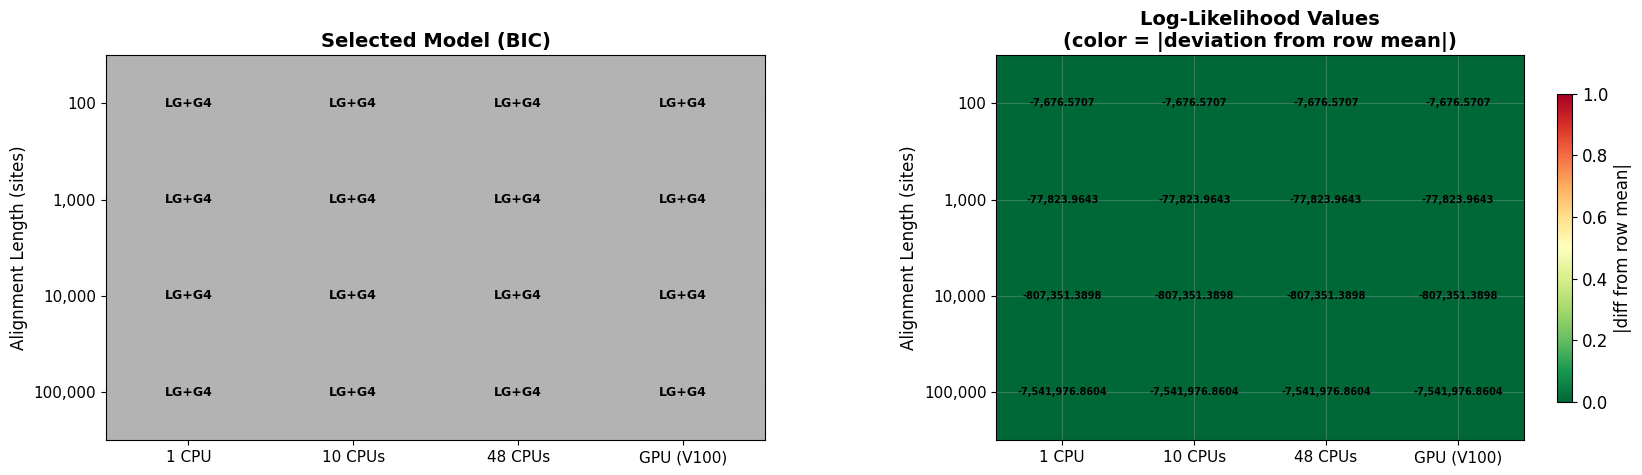

Heatmap saved.


In [5]:
import matplotlib.colors as mcolors

# --- 1. Selected Model Heatmap ---
model_pivot = df.pivot_table(index='length', columns='workflow_label', values='best_model', aggfunc='first')
model_cols = [c for c in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)'] if c in model_pivot.columns]
model_pivot = model_pivot[model_cols]

all_models = sorted(model_pivot.stack().unique())
model_to_int = {m: i for i, m in enumerate(all_models)}
model_numeric = model_pivot.map(lambda x: model_to_int.get(x, -1) if pd.notna(x) else -1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))

n_models = len(all_models)
cmap = plt.cm.get_cmap('Set2', max(n_models, 2))

im1 = ax1.imshow(model_numeric.values, cmap=cmap, aspect='auto', vmin=-0.5, vmax=n_models-0.5)
ax1.set_xticks(range(len(model_cols)))
ax1.set_xticklabels(model_cols, fontsize=11)
ax1.set_yticks(range(len(model_pivot.index)))
ax1.set_yticklabels([f'{l:,}' for l in model_pivot.index], fontsize=11)
ax1.set_ylabel('Alignment Length (sites)', fontsize=12)
ax1.set_title('Selected Model (BIC)', fontsize=14, fontweight='bold')

for i in range(len(model_pivot.index)):
    for j in range(len(model_cols)):
        val = model_pivot.iloc[i, j]
        if pd.notna(val):
            ax1.text(j, i, val, ha='center', va='center', fontsize=9, fontweight='bold')
        else:
            ax1.text(j, i, 'N/A', ha='center', va='center', fontsize=9, color='gray')

# --- 2. Log-Likelihood Heatmap ---
lnl_pivot_full = df.pivot_table(index='length', columns='workflow_label', values='log_likelihood', aggfunc='first')
lnl_cols = [c for c in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)'] if c in lnl_pivot_full.columns]
lnl_pivot_full = lnl_pivot_full[lnl_cols]

row_means = lnl_pivot_full.mean(axis=1)
lnl_diff_from_mean = lnl_pivot_full.sub(row_means, axis=0).abs()

max_diff = lnl_diff_from_mean.max().max()
if pd.isna(max_diff) or max_diff == 0:
    max_diff = 1.0
norm = mcolors.Normalize(vmin=0, vmax=max_diff)

im2 = ax2.imshow(lnl_diff_from_mean.fillna(0).values, cmap='RdYlGn_r', aspect='auto', norm=norm)

ax2.set_xticks(range(len(lnl_cols)))
ax2.set_xticklabels(lnl_cols, fontsize=11)
ax2.set_yticks(range(len(lnl_pivot_full.index)))
ax2.set_yticklabels([f'{l:,}' for l in lnl_pivot_full.index], fontsize=11)
ax2.set_ylabel('Alignment Length (sites)', fontsize=12)
ax2.set_title('Log-Likelihood Values\n(color = |deviation from row mean|)', fontsize=14, fontweight='bold')

for i in range(len(lnl_pivot_full.index)):
    for j in range(len(lnl_cols)):
        val = lnl_pivot_full.iloc[i, j]
        if pd.notna(val):
            txt = f'{val:,.4f}'
            ax2.text(j, i, txt, ha='center', va='center', fontsize=7, fontweight='bold')
        else:
            ax2.text(j, i, 'N/A', ha='center', va='center', fontsize=9, color='gray')

plt.colorbar(im2, ax=ax2, label='|diff from row mean|', shrink=0.8)
plt.subplots_adjust(wspace=0.35)
plt.savefig(os.path.join(SAVE_DIR, 'model_likelihood_heatmap.png'), dpi=150)
plt.show()
print('Heatmap saved.')

## 3. Per-Model Log-Likelihood Comparison

Comparing the exact log-likelihood values for **every model** tested by ModelFinder across all workflows. This shows whether CPU and GPU produce identical per-model likelihoods.

In [6]:
def parse_model_table(filepath):
    """Parse the 'List of models sorted by BIC scores' table from .iqtree file.
    Returns a list of dicts with model, lnL, AIC, BIC for each model tested.
    """
    models = []
    with open(filepath, 'r') as f:
        content = f.read()
    
    table_match = re.search(r'Model\s+LogL\s+AIC.*?BIC.*?\n(.*?)(?:\n\n|\nAkaike|\nBayesian)', content, re.DOTALL)
    if not table_match:
        return models
    
    for line in table_match.group(1).strip().split('\n'):
        line = line.strip()
        if not line or line.startswith('---'):
            continue
        parts = line.split()
        if len(parts) >= 9:
            try:
                model_name = parts[0]
                lnl = float(parts[1])
                aic = float(parts[2])
                bic = float(parts[-3])
                models.append({'model': model_name, 'lnL': lnl, 'AIC': aic, 'BIC': bic})
            except (ValueError, IndexError):
                continue
    return models

# Parse per-model likelihoods for all workflows and lengths
all_model_records = []
lengths = [100, 1000, 10000, 100000]
workflows = ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC']
wf_labels = {'VANILA': '1 CPU', 'OMP_10': '10 CPUs', 'OMP_48': '48 CPUs', 'OPENACC': 'GPU (V100)'}

for length in lengths:
    tree_dir = os.path.join(RESULTS_DIR, f'len_{length}', 'tree_1')
    direct_dir = os.path.join(RESULTS_DIR, f'len_{length}')
    
    for wf in workflows:
        iqtree_files = []
        for sdir in [tree_dir, direct_dir]:
            if os.path.isdir(sdir):
                iqtree_files = glob.glob(os.path.join(sdir, f'*_{wf}_*.iqtree'))
                if iqtree_files:
                    break
        if not iqtree_files:
            continue
        models = parse_model_table(iqtree_files[0])
        for m in models:
            m['length'] = length
            m['workflow'] = wf
            m['workflow_label'] = wf_labels[wf]
            all_model_records.append(m)

model_df = pd.DataFrame(all_model_records)
print(f"Parsed {len(model_df)} model evaluations across {model_df['length'].nunique()} alignment lengths and {model_df['workflow'].nunique()} workflows")
print(f"Unique models tested: {model_df['model'].nunique()}")

model_df.head(10)

Parsed 1732 model evaluations across 4 alignment lengths and 4 workflows
Unique models tested: 122


,model,lnL,AIC,BIC,length,workflow,workflow_label
0,LG+G4,-7676.571,15749.141,16264.965,100,VANILA,1 CPU
1,LG+I+G4,-7676.624,15751.247,16269.676,100,VANILA,1 CPU
2,LG+R4,-7675.512,15757.024,16285.873,100,VANILA,1 CPU
3,LG+I+R4,-7675.540,15759.081,16290.535,100,VANILA,1 CPU
4,Q.PFAM+G4,-7690.034,15776.068,16291.892,100,VANILA,1 CPU
5,LG+R5,-7675.263,15760.526,16294.586,100,VANILA,1 CPU
6,Q.PFAM+I+G4,-7690.042,15778.084,16296.513,100,VANILA,1 CPU
7,LG+I+R5,-7675.284,15762.567,16299.232,100,VANILA,1 CPU
8,LG+R3,-7690.370,15782.739,16306.378,100,VANILA,1 CPU
9,LG+I+R3,-7690.434,15784.867,16311.112,100,VANILA,1 CPU


In [7]:
# --- Per-model lnL comparison: compute max |diff| across workflows for each (model, length) ---
from matplotlib.ticker import MaxNLocator
import numpy as np

lnl_pivot = df.pivot_table(index='length', columns='workflow_label', values='log_likelihood', aggfunc='first')
lnl_pivot = lnl_pivot[[c for c in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)'] if c in lnl_pivot.columns]]

comparison_rows = []
for length in sorted(model_df['length'].unique()):
    len_df = model_df[model_df['length'] == length]
    for model_name in len_df['model'].unique():
        m_df = len_df[len_df['model'] == model_name]
        if len(m_df) < 2:
            continue
        wf_lnl = {}
        for wf in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)']:
            wf_rows = m_df[m_df['workflow_label'] == wf]
            if len(wf_rows) > 0:
                wf_lnl[wf] = float(wf_rows['lnL'].iloc[0])
        
        if len(wf_lnl) < 2:
            continue
        
        vals = list(wf_lnl.values())
        abs_diff = max(vals) - min(vals)
        
        row = {
            'length': length,
            'model': model_name,
            'max_lnL': max(vals),
            'min_lnL': min(vals),
            'abs_diff': abs_diff,
            'n_workflows': len(wf_lnl),
        }
        for wf in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)']:
            row[f'lnL_{wf}'] = wf_lnl.get(wf, float('nan'))
        comparison_rows.append(row)

comp_df = pd.DataFrame(comparison_rows)
comp_df = comp_df[comp_df['n_workflows'] >= 2]

print(f"Compared {len(comp_df)} (model, length) pairs across workflows\n")

print("=== Maximum absolute lnL difference across workflows ===")
for length in sorted(comp_df['length'].unique()):
    sub = comp_df[comp_df['length'] == length]
    max_diff = sub['abs_diff'].max()
    mean_diff = sub['abs_diff'].mean()
    n_exact = (sub['abs_diff'] == 0).sum()
    n_total = len(sub)
    worst_model = sub.loc[sub['abs_diff'].idxmax(), 'model'] if max_diff > 0 else 'all identical'
    print(f"  len={length:>10,}: max_diff={max_diff:.4f}  mean_diff={mean_diff:.6f}  exact_match={n_exact}/{n_total}  worst_model={worst_model}")

print(f"\nOverall max |diff| across ALL models and lengths: {comp_df['abs_diff'].max():.6f}")
print(f"Overall mean |diff|: {comp_df['abs_diff'].mean():.8f}")

Compared 433 (model, length) pairs across workflows

=== Maximum absolute lnL difference across workflows ===
  len=       100: max_diff=0.0010  mean_diff=0.000016  exact_match=120/122  worst_model=LG+I+R3
  len=     1,000: max_diff=0.0080  mean_diff=0.000131  exact_match=114/122  worst_model=LG+I+R5
  len=    10,000: max_diff=0.0110  mean_diff=0.000434  exact_match=101/122  worst_model=Q.BIRD+I+G4
  len=   100,000: max_diff=0.2620  mean_diff=0.005970  exact_match=53/67  worst_model=LG+I+R5

Overall max |diff| across ALL models and lengths: 0.262000
Overall mean |diff|: 0.00108776


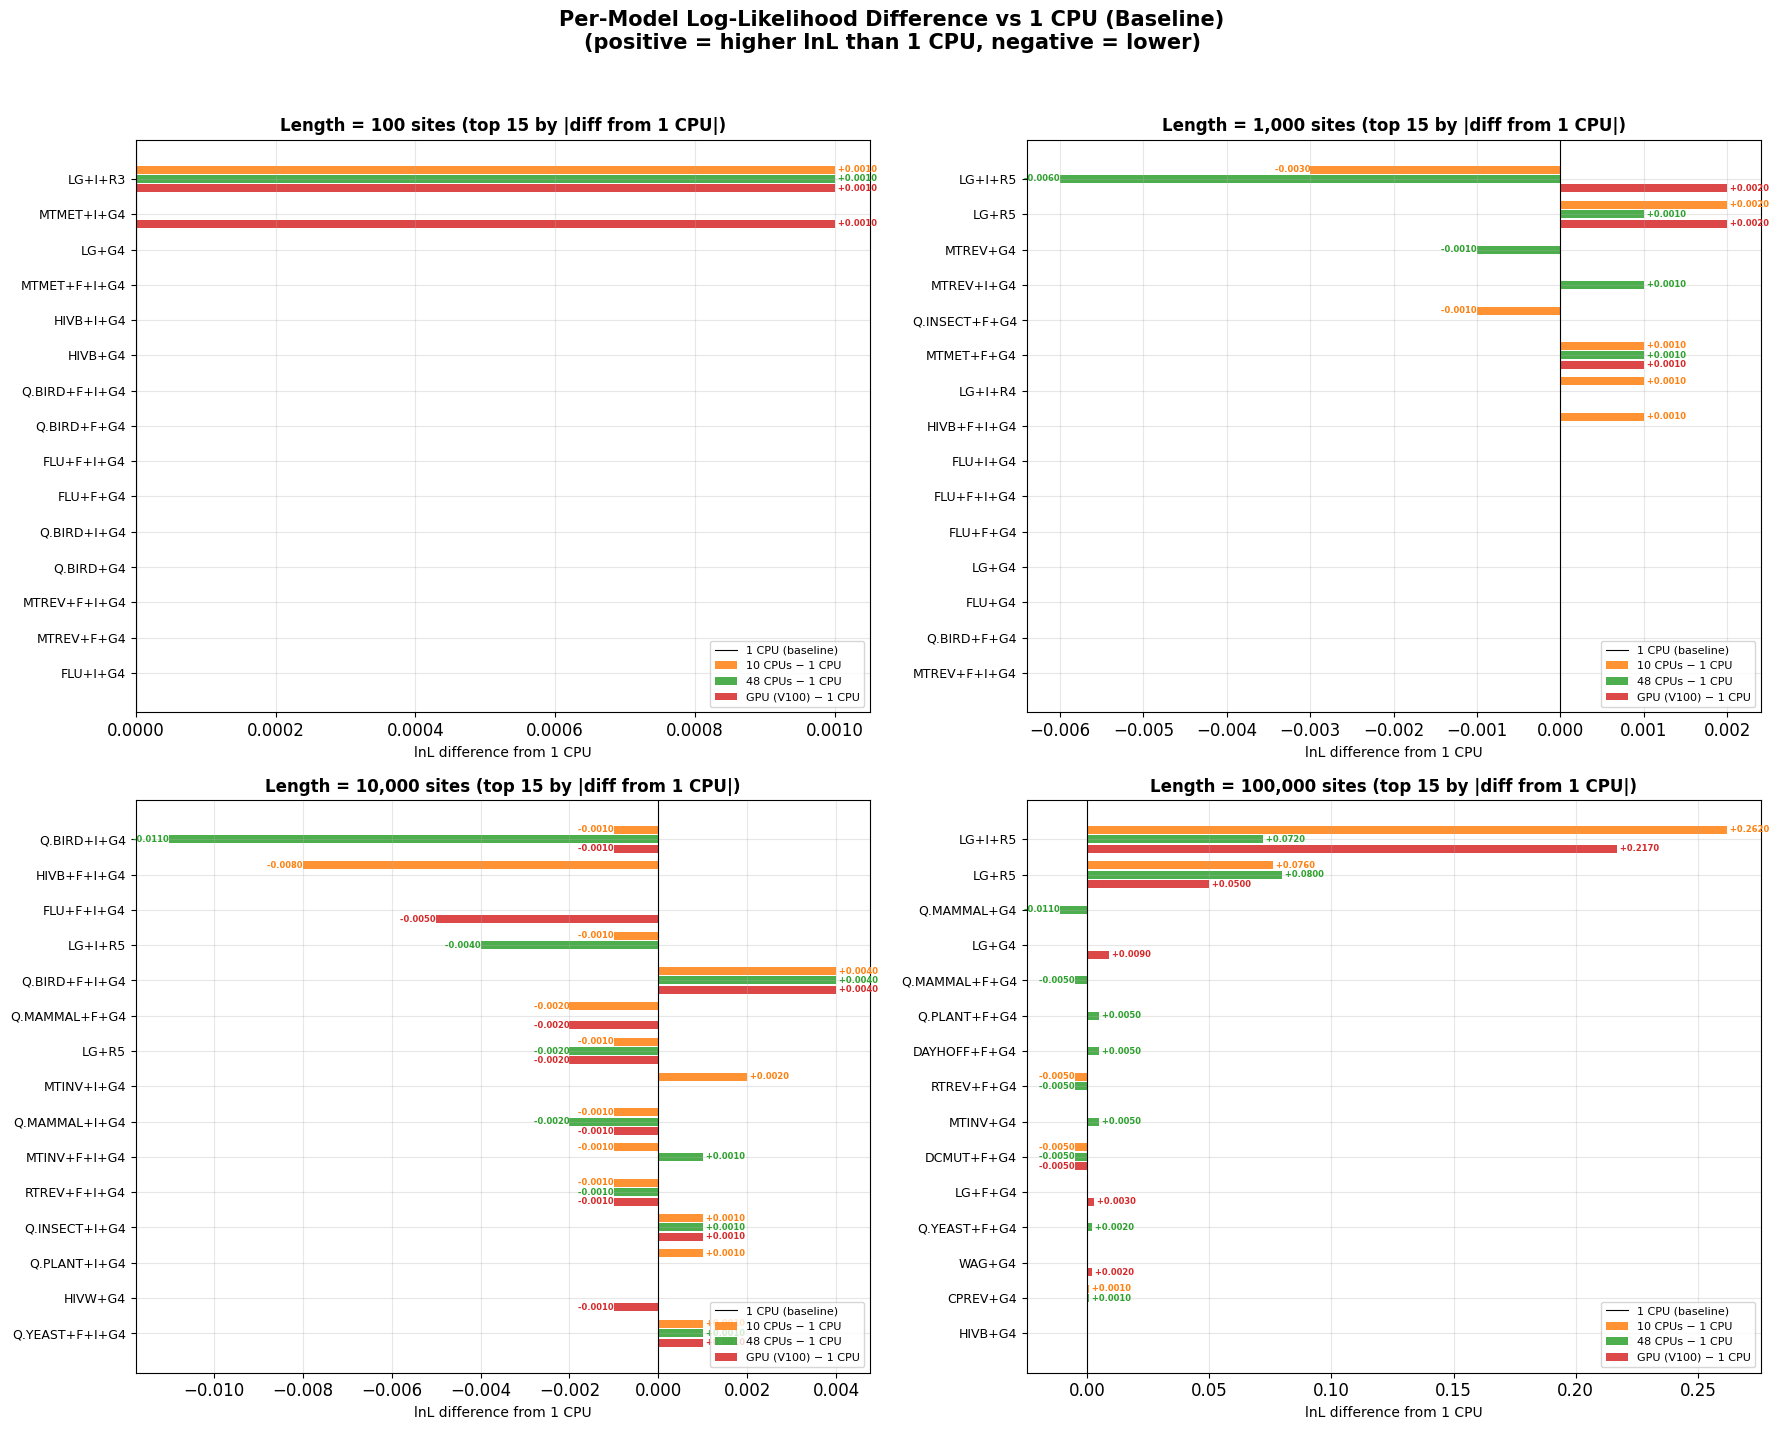

Per-model lnL differences plot saved.


In [8]:
# --- Per-model lnL: show each workflow's difference FROM 1 CPU (baseline) ---
import numpy as np

wf_compare = ['10 CPUs', '48 CPUs', 'GPU (V100)']
wf_colors_diff = {'10 CPUs': '#ff7f0e', '48 CPUs': '#2ca02c', 'GPU (V100)': '#d62728'}

plot_lengths = sorted(comp_df['length'].unique())
n_plots = len(plot_lengths)
ncols = 2
nrows = (n_plots + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 7 * nrows))
axes = axes.flatten()

for idx, length in enumerate(plot_lengths):
    ax = axes[idx]
    sub = comp_df[comp_df['length'] == length].copy()
    sub = sub[sub['lnL_1 CPU'].notna()].copy()
    
    for wf in wf_compare:
        col = f'lnL_{wf}'
        sub[f'diff_{wf}'] = sub[col] - sub['lnL_1 CPU']
    
    sub['max_abs_diff_vs_1cpu'] = sub[[f'diff_{wf}' for wf in wf_compare]].abs().max(axis=1)
    sub = sub.sort_values('max_abs_diff_vs_1cpu', ascending=False)
    
    top_n = min(15, len(sub))
    top = sub.head(top_n)
    
    model_names = top['model'].tolist()
    n_models = len(model_names)
    n_wfs = len(wf_compare)
    bar_height = 0.8 / n_wfs
    y = np.arange(n_models)
    
    for wf_idx, wf in enumerate(wf_compare):
        diffs = top[f'diff_{wf}'].values
        offset = (wf_idx - (n_wfs - 1) / 2) * bar_height
        ax.barh(y + offset, diffs, bar_height * 0.85,
                label=f'{wf} − 1 CPU', color=wf_colors_diff[wf], alpha=0.85)
        
        for i, d in enumerate(diffs):
            if not np.isnan(d) and abs(d) > 0:
                ha = 'left' if d >= 0 else 'right'
                ax.text(d, y[i] + offset, f' {d:+.4f}', va='center', ha=ha, fontsize=6,
                        color=wf_colors_diff[wf], fontweight='bold')
    
    ax.set_yticks(y)
    ax.set_yticklabels(model_names, fontsize=9)
    ax.invert_yaxis()
    ax.axvline(x=0, color='black', linewidth=0.8, label='1 CPU (baseline)')
    ax.set_xlabel('lnL difference from 1 CPU', fontsize=10)
    ax.set_title(f'Length = {length:,} sites (top {top_n} by |diff from 1 CPU|)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='x', alpha=0.3)

for idx in range(n_plots, nrows * ncols):
    axes[idx].set_visible(False)

plt.suptitle('Per-Model Log-Likelihood Difference vs 1 CPU (Baseline)\n(positive = higher lnL than 1 CPU, negative = lower)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'per_model_lnl_differences.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Per-model lnL differences plot saved.')

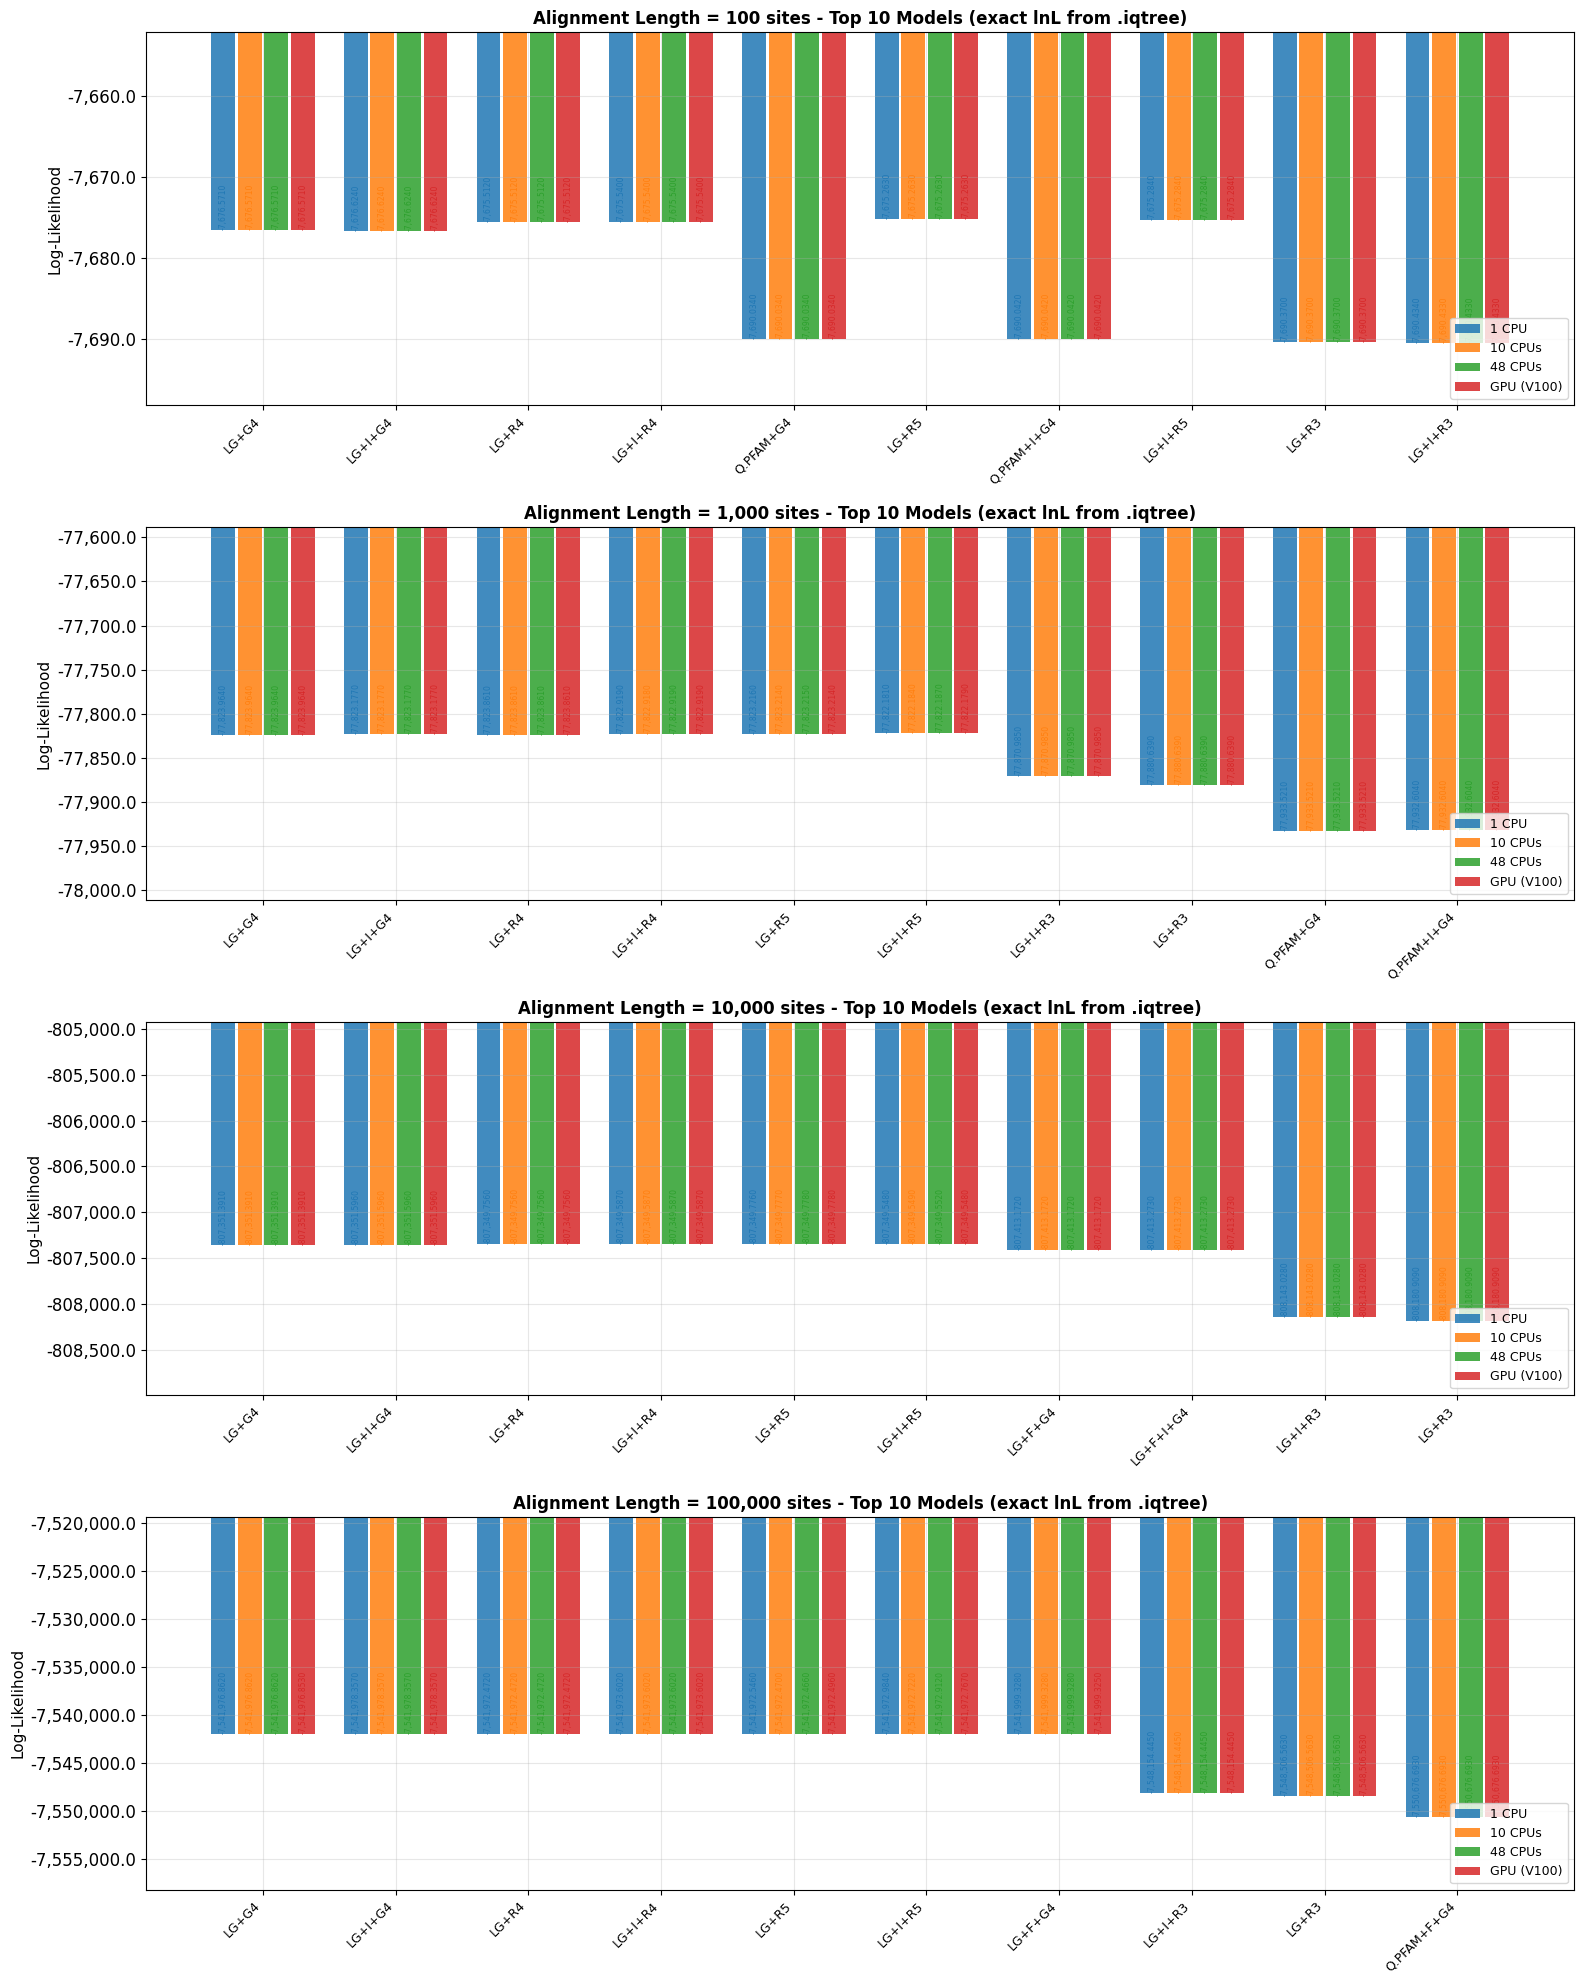

Per-model exact lnL bar chart saved.


In [9]:
# --- Figure 2: Exact lnL values for top-10 BIC models, all workflows side-by-side ---
import numpy as np

wf_display_order = ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)']
wf_colors_bar = {'1 CPU': '#1f77b4', '10 CPUs': '#ff7f0e', '48 CPUs': '#2ca02c', 'GPU (V100)': '#d62728'}

plot_lengths = sorted(comp_df['length'].unique())
fig, axes = plt.subplots(len(plot_lengths), 1, figsize=(16, 5 * len(plot_lengths)))
if len(plot_lengths) == 1:
    axes = [axes]

for idx, length in enumerate(plot_lengths):
    ax = axes[idx]
    len_df = model_df[model_df['length'] == length]
    
    top_models_bic = len_df.groupby('model')['BIC'].min().nsmallest(10).index.tolist()
    top_df = len_df[len_df['model'].isin(top_models_bic)]
    
    model_order = top_models_bic
    n_models = len(model_order)
    wfs_present = [w for w in wf_display_order if w in top_df['workflow_label'].unique()]
    n_wfs = len(wfs_present)
    bar_width = 0.8 / n_wfs
    x = np.arange(n_models)
    
    for wf_idx, wf in enumerate(wfs_present):
        wf_data = top_df[top_df['workflow_label'] == wf]
        lnl_vals = []
        for m in model_order:
            row = wf_data[wf_data['model'] == m]
            lnl_vals.append(row['lnL'].values[0] if len(row) > 0 else float('nan'))
        
        offset = (wf_idx - (n_wfs - 1) / 2) * bar_width
        ax.bar(x + offset, lnl_vals, bar_width * 0.9, label=wf, color=wf_colors_bar[wf], alpha=0.85)
        
        for i, v in enumerate(lnl_vals):
            if not np.isnan(v):
                ax.text(x[i] + offset, v, f'{v:,.4f}', ha='center', va='bottom', fontsize=5.5,
                        rotation=90, color=wf_colors_bar[wf])
    
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, fontsize=9, rotation=45, ha='right')
    ax.set_ylabel('Log-Likelihood', fontsize=11)
    ax.set_title(f'Alignment Length = {length:,} sites - Top 10 Models (exact lnL from .iqtree)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    
    all_vals = [v for v in top_df['lnL'] if not np.isnan(v)]
    if all_vals:
        ymin, ymax = min(all_vals), max(all_vals)
        margin = max(abs(ymax - ymin) * 0.15, abs(ymin) * 0.001)
        ax.set_ylim(ymin - margin, ymax + margin * 3)
    
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'{v:,.1f}'))

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'per_model_exact_lnl_bars.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Per-model exact lnL bar chart saved.')

In [10]:
# --- Table: Exact lnL values for top-10 BIC models at each length ---
for length in sorted(comp_df['length'].unique()):
    len_df = model_df[model_df['length'] == length]
    top_models_bic = len_df.groupby('model')['BIC'].min().nsmallest(10).index.tolist()
    
    rows = []
    for m in top_models_bic:
        m_df = len_df[len_df['model'] == m]
        row = {'Model': m}
        lnl_vals = []
        for wf in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)']:
            wf_row = m_df[m_df['workflow_label'] == wf]
            if len(wf_row) > 0:
                val = wf_row['lnL'].values[0]
                row[f'lnL ({wf})'] = f'{val:.4f}'
                lnl_vals.append(val)
            else:
                row[f'lnL ({wf})'] = 'N/A'
        if len(lnl_vals) >= 2:
            row['|max diff|'] = f'{max(lnl_vals) - min(lnl_vals):.6f}'
        else:
            row['|max diff|'] = 'N/A'
        rows.append(row)
    
    table_df = pd.DataFrame(rows)
    print(f"\nAlignment Length = {length:,} sites - Top 10 Models by BIC")
    print("=" * 120)
    with pd.option_context('display.max_colwidth', None, 'display.width', 200):
        display(table_df)


Alignment Length = 100 sites - Top 10 Models by BIC


,Model,lnL (1 CPU),lnL (10 CPUs),lnL (48 CPUs),lnL (GPU (V100)),|max diff|
0,LG+G4,-7676.5710,-7676.5710,-7676.5710,-7676.5710,0.000000
1,LG+I+G4,-7676.6240,-7676.6240,-7676.6240,-7676.6240,0.000000
2,LG+R4,-7675.5120,-7675.5120,-7675.5120,-7675.5120,0.000000
3,LG+I+R4,-7675.5400,-7675.5400,-7675.5400,-7675.5400,0.000000
4,Q.PFAM+G4,-7690.0340,-7690.0340,-7690.0340,-7690.0340,0.000000
5,LG+R5,-7675.2630,-7675.2630,-7675.2630,-7675.2630,0.000000
6,Q.PFAM+I+G4,-7690.0420,-7690.0420,-7690.0420,-7690.0420,0.000000
7,LG+I+R5,-7675.2840,-7675.2840,-7675.2840,-7675.2840,0.000000
8,LG+R3,-7690.3700,-7690.3700,-7690.3700,-7690.3700,0.000000
9,LG+I+R3,-7690.4340,-7690.4330,-7690.4330,-7690.4330,0.001000



Alignment Length = 1,000 sites - Top 10 Models by BIC


,Model,lnL (1 CPU),lnL (10 CPUs),lnL (48 CPUs),lnL (GPU (V100)),|max diff|
0,LG+G4,-77823.9640,-77823.9640,-77823.9640,-77823.9640,0.000000
1,LG+I+G4,-77823.1770,-77823.1770,-77823.1770,-77823.1770,0.000000
2,LG+R4,-77823.8610,-77823.8610,-77823.8610,-77823.8610,0.000000
3,LG+I+R4,-77822.9190,-77822.9180,-77822.9190,-77822.9190,0.001000
4,LG+R5,-77823.2160,-77823.2140,-77823.2150,-77823.2140,0.002000
5,LG+I+R5,-77822.1810,-77822.1840,-77822.1870,-77822.1790,0.008000
6,LG+I+R3,-77870.9850,-77870.9850,-77870.9850,-77870.9850,0.000000
7,LG+R3,-77880.6390,-77880.6390,-77880.6390,-77880.6390,0.000000
8,Q.PFAM+G4,-77933.5210,-77933.5210,-77933.5210,-77933.5210,0.000000
9,Q.PFAM+I+G4,-77932.6040,-77932.6040,-77932.6040,-77932.6040,0.000000



Alignment Length = 10,000 sites - Top 10 Models by BIC


,Model,lnL (1 CPU),lnL (10 CPUs),lnL (48 CPUs),lnL (GPU (V100)),|max diff|
0,LG+G4,-807351.3910,-807351.3910,-807351.3910,-807351.3910,0.000000
1,LG+I+G4,-807351.5960,-807351.5960,-807351.5960,-807351.5960,0.000000
2,LG+R4,-807349.7560,-807349.7560,-807349.7560,-807349.7560,0.000000
3,LG+I+R4,-807349.5870,-807349.5870,-807349.5870,-807349.5870,0.000000
4,LG+R5,-807349.7760,-807349.7770,-807349.7780,-807349.7780,0.002000
5,LG+I+R5,-807349.5480,-807349.5490,-807349.5520,-807349.5480,0.004000
6,LG+F+G4,-807413.1720,-807413.1720,-807413.1720,-807413.1720,0.000000
7,LG+F+I+G4,-807413.2730,-807413.2730,-807413.2730,-807413.2730,0.000000
8,LG+I+R3,-808143.0280,-808143.0280,-808143.0280,-808143.0280,0.000000
9,LG+R3,-808180.9090,-808180.9090,-808180.9090,-808180.9090,0.000000



Alignment Length = 100,000 sites - Top 10 Models by BIC


,Model,lnL (1 CPU),lnL (10 CPUs),lnL (48 CPUs),lnL (GPU (V100)),|max diff|
0,LG+G4,-7541976.8620,-7541976.8620,-7541976.8620,-7541976.8530,0.009000
1,LG+I+G4,-7541978.3570,-7541978.3570,-7541978.3570,-7541978.3570,0.000000
2,LG+R4,-7541972.4720,-7541972.4720,-7541972.4720,-7541972.4720,0.000000
3,LG+I+R4,-7541973.6020,-7541973.6020,-7541973.6020,-7541973.6020,0.000000
4,LG+R5,-7541972.5460,-7541972.4700,-7541972.4660,-7541972.4960,0.080000
5,LG+I+R5,-7541972.9840,-7541972.7220,-7541972.9120,-7541972.7670,0.262000
6,LG+F+G4,-7541999.3280,-7541999.3280,-7541999.3280,-7541999.3250,0.003000
7,LG+I+R3,-7548154.4450,-7548154.4450,-7548154.4450,-7548154.4450,0.000000
8,LG+R3,-7548506.5630,-7548506.5630,-7548506.5630,-7548506.5630,0.000000
9,Q.PFAM+F+G4,-7550676.6930,-7550676.6930,-7550676.6930,-7550676.6930,0.000000


## 4. Wall-Clock Runtime Comparison

In [11]:
time_pivot = df.pivot_table(index='length', columns='workflow_label', values='wall_time_sec', aggfunc='first')
time_pivot = time_pivot[[c for c in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)'] if c in time_pivot.columns]]

print("Wall-clock time (seconds):")
print(time_pivot.to_string(float_format='%.1f'))
print()

def fmt_time(sec):
    if pd.isna(sec): return 'N/A'
    if sec < 60: return f'{sec:.1f}s'
    if sec < 3600: return f'{sec/60:.1f}m'
    return f'{sec/3600:.1f}h'

print("\nWall-clock time (human-readable):")
print(time_pivot.map(fmt_time).to_string())

import matplotlib.ticker as ticker
colors = {'1 CPU': '#1f77b4', '10 CPUs': '#ff7f0e', '48 CPUs': '#2ca02c', 'GPU (V100)': '#d62728'}
markers = {'1 CPU': 'o', '10 CPUs': 's', '48 CPUs': '^', 'GPU (V100)': 'D'}

Wall-clock time (seconds):
workflow_label   1 CPU  10 CPUs  48 CPUs  GPU (V100)
length                                              
100               46.2     10.6     16.5       165.7
1000             551.2     90.9     57.9       246.8
10000           5343.9    587.1    207.7       352.3
100000         41912.3   4858.4   1384.0      1071.1


Wall-clock time (human-readable):
workflow_label  1 CPU 10 CPUs 48 CPUs GPU (V100)
length                                          
100             46.2s   10.6s   16.5s       2.8m
1000             9.2m    1.5m   57.9s       4.1m
10000            1.5h    9.8m    3.5m       5.9m
100000          11.6h    1.3h   23.1m      17.9m


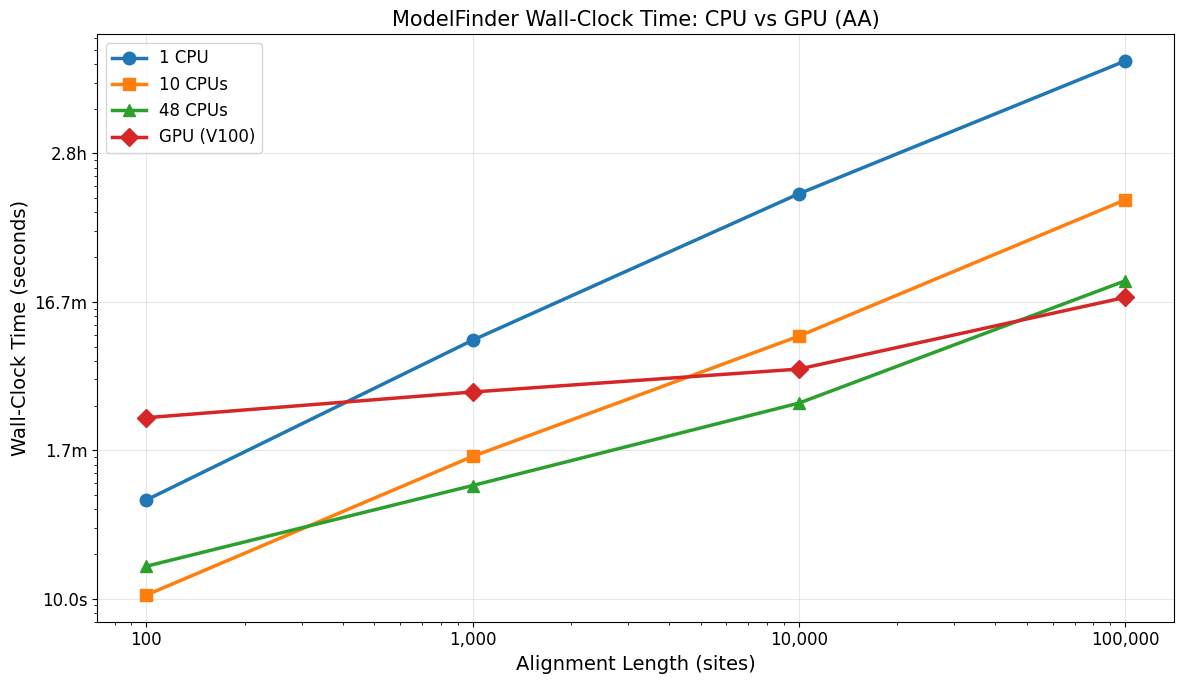

In [12]:
# Wall-clock time plot
fig, ax = plt.subplots(figsize=(12, 7))

for wf in [c for c in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)'] if c in time_pivot.columns]:
    data = time_pivot[wf].dropna()
    ax.plot(data.index, data.values, marker=markers[wf], label=wf,
            color=colors[wf], linewidth=2.5, markersize=9)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Alignment Length (sites)', fontsize=14)
ax.set_ylabel('Wall-Clock Time (seconds)', fontsize=14)
ax.set_title('ModelFinder Wall-Clock Time: CPU vs GPU (AA)', fontsize=15)
ax.legend(fontsize=12, loc='upper left')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: fmt_time(x)))

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_time_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

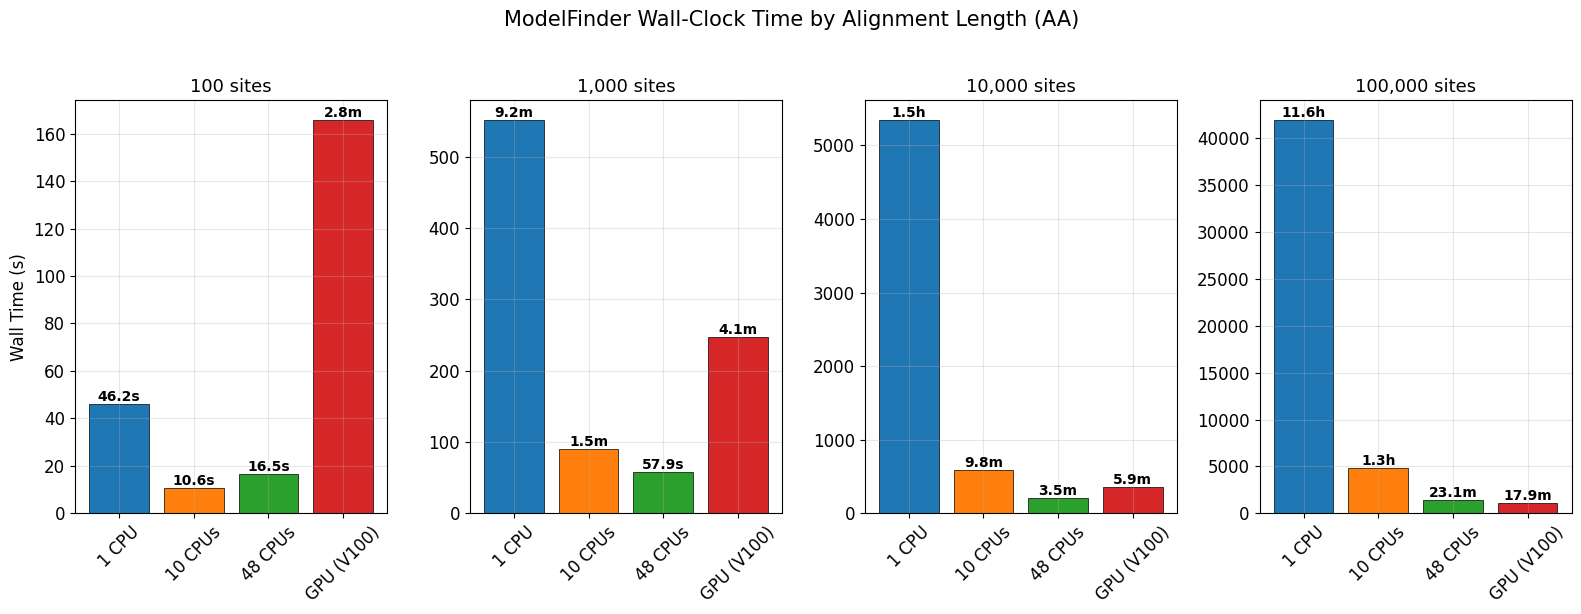

In [13]:
# Bar chart for wall-clock time at each alignment length
available_wfs = [c for c in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)'] if c in time_pivot.columns]
valid_lengths = time_pivot.dropna(thresh=3).index

fig, axes = plt.subplots(1, len(valid_lengths), figsize=(4*len(valid_lengths), 6), sharey=False)
if len(valid_lengths) == 1:
    axes = [axes]

for i, length in enumerate(valid_lengths):
    ax = axes[i]
    vals = []
    labels = []
    bar_colors = []
    for wf in available_wfs:
        v = time_pivot.loc[length, wf]
        if not pd.isna(v):
            vals.append(v)
            labels.append(wf)
            bar_colors.append(colors[wf])
    
    bars = ax.bar(labels, vals, color=bar_colors, edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt_time(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_title(f'{length:,} sites', fontsize=13)
    ax.set_ylabel('Wall Time (s)' if i == 0 else '')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('ModelFinder Wall-Clock Time by Alignment Length (AA)', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_time_bars.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Speedup Analysis

In [14]:
# Calculate speedup relative to 1 CPU
if '1 CPU' in time_pivot.columns:
    speedup_df = pd.DataFrame(index=time_pivot.index)
    for wf in available_wfs:
        speedup_df[wf] = time_pivot['1 CPU'] / time_pivot[wf]
    
    print("Speedup vs 1 CPU (wall-clock):")
    print(speedup_df.to_string(float_format='%.2f'))
    print()
    
    if 'GPU (V100)' in time_pivot.columns and '48 CPUs' in time_pivot.columns:
        gpu_vs_48 = time_pivot['48 CPUs'] / time_pivot['GPU (V100)']
        print("GPU speedup vs 48 CPUs:")
        for length in gpu_vs_48.dropna().index:
            print(f"  len={length:>8,}: {gpu_vs_48[length]:.2f}x")

Speedup vs 1 CPU (wall-clock):
        1 CPU  10 CPUs  48 CPUs  GPU (V100)
length                                     
100      1.00     4.37     2.79        0.28
1000     1.00     6.07     9.53        2.23
10000    1.00     9.10    25.73       15.17
100000   1.00     8.63    30.28       39.13

GPU speedup vs 48 CPUs:
  len=     100: 0.10x
  len=   1,000: 0.23x
  len=  10,000: 0.59x
  len= 100,000: 1.29x


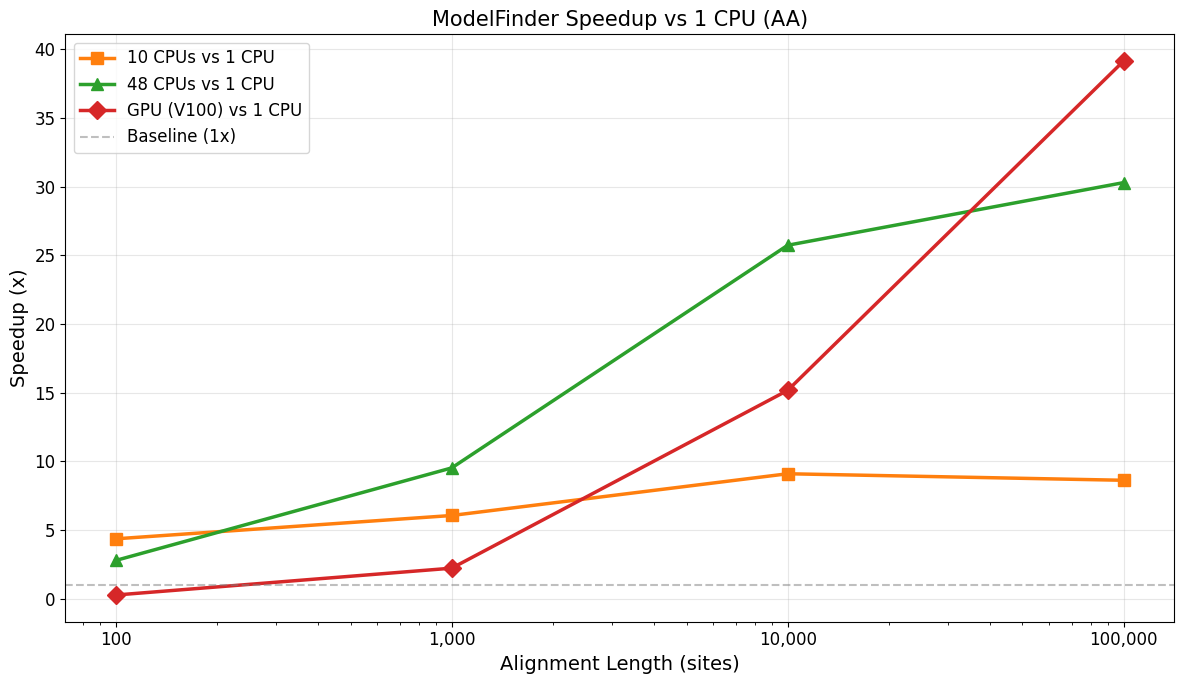

In [15]:
# Speedup plot
if '1 CPU' in time_pivot.columns:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    for wf in available_wfs:
        if wf == '1 CPU':
            continue
        data = speedup_df[wf].dropna()
        ax.plot(data.index, data.values, marker=markers[wf], label=f'{wf} vs 1 CPU',
                color=colors[wf], linewidth=2.5, markersize=9)
    
    ax.set_xscale('log')
    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Baseline (1x)')
    ax.set_xlabel('Alignment Length (sites)', fontsize=14)
    ax.set_ylabel('Speedup (x)', fontsize=14)
    ax.set_title('ModelFinder Speedup vs 1 CPU (AA)', fontsize=15)
    ax.legend(fontsize=12)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'speedup_vs_1cpu.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 6. CPU Time (Total Compute) Comparison

In [16]:
cpu_pivot = df.pivot_table(index='length', columns='workflow_label', values='cpu_time_sec', aggfunc='first')
cpu_pivot = cpu_pivot[[c for c in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)'] if c in cpu_pivot.columns]]

print("Total CPU time (seconds):")
print(cpu_pivot.to_string(float_format='%.1f'))
print()
print("CPU time (human-readable):")
print(cpu_pivot.map(fmt_time).to_string())
print()

if '1 CPU' in time_pivot.columns:
    print("\nParallelism overhead (CPU_time / wall_time):")
    for wf in available_wfs:
        ratio = cpu_pivot[wf] / time_pivot[wf]
        for length in ratio.dropna().index:
            print(f"  {wf:>12s}, len={length:>8,}: {ratio[length]:.2f}x")

Total CPU time (seconds):
workflow_label   1 CPU  10 CPUs  48 CPUs  GPU (V100)
length                                              
100               46.1    103.7    200.4       165.7
1000             547.7    881.1   2708.1       246.5
10000           5278.8   5788.6   9516.0       352.3
100000         41558.9  45359.7  61129.2      1069.3

CPU time (human-readable):
workflow_label  1 CPU 10 CPUs 48 CPUs GPU (V100)
length                                          
100             46.1s    1.7m    3.3m       2.8m
1000             9.1m   14.7m   45.1m       4.1m
10000            1.5h    1.6h    2.6h       5.9m
100000          11.5h   12.6h   17.0h      17.8m


Parallelism overhead (CPU_time / wall_time):
         1 CPU, len=     100: 1.00x
         1 CPU, len=   1,000: 0.99x
         1 CPU, len=  10,000: 0.99x
         1 CPU, len= 100,000: 0.99x
       10 CPUs, len=     100: 9.80x
       10 CPUs, len=   1,000: 9.69x
       10 CPUs, len=  10,000: 9.86x
       10 CPUs, len= 100,000: 9.34x

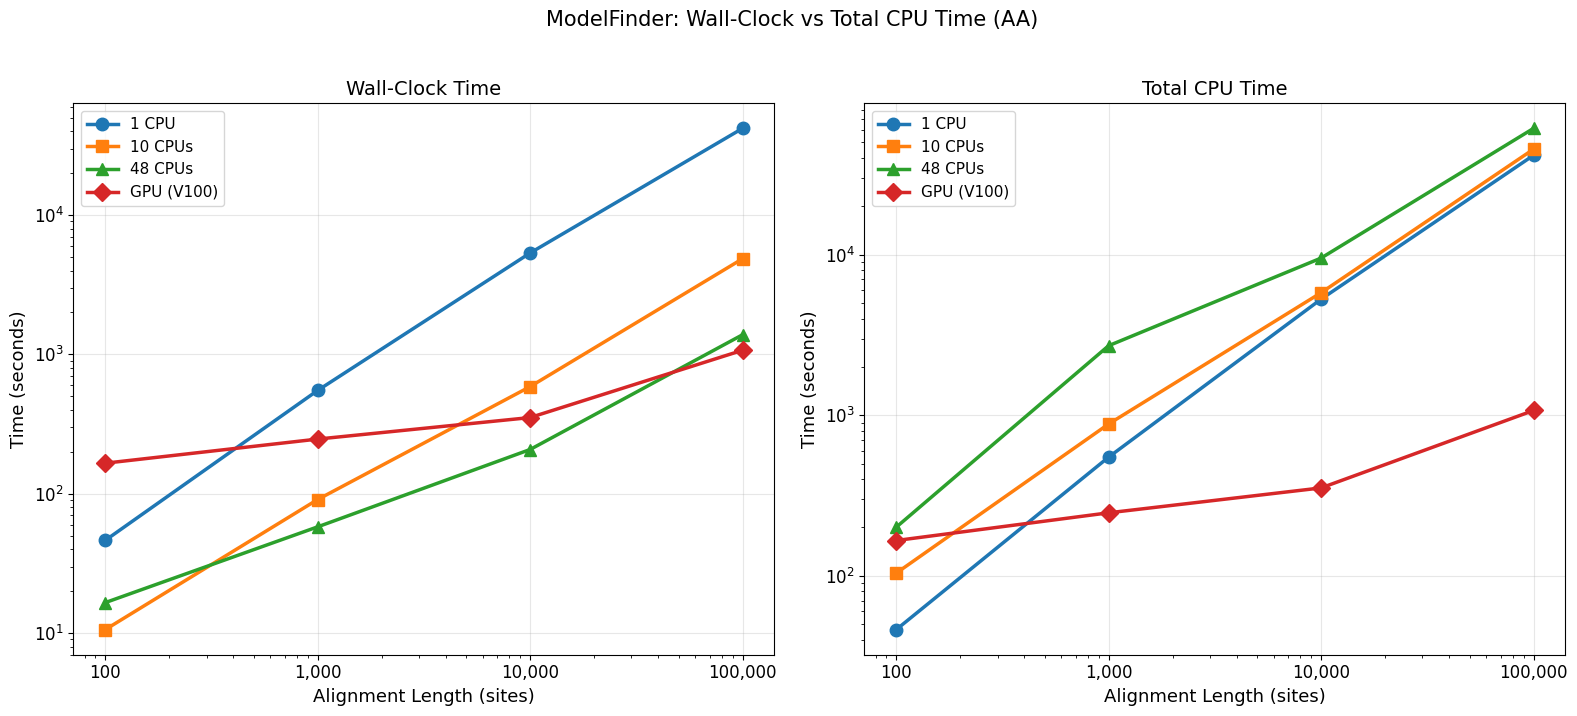

In [17]:
# CPU time vs wall time comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for wf in available_wfs:
    data = time_pivot[wf].dropna()
    ax1.plot(data.index, data.values, marker=markers[wf], label=wf,
            color=colors[wf], linewidth=2.5, markersize=9)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Alignment Length (sites)', fontsize=13)
ax1.set_ylabel('Time (seconds)', fontsize=13)
ax1.set_title('Wall-Clock Time', fontsize=14)
ax1.legend(fontsize=11)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for wf in available_wfs:
    data = cpu_pivot[wf].dropna()
    ax2.plot(data.index, data.values, marker=markers[wf], label=wf,
            color=colors[wf], linewidth=2.5, markersize=9)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Alignment Length (sites)', fontsize=13)
ax2.set_ylabel('Time (seconds)', fontsize=13)
ax2.set_title('Total CPU Time', fontsize=14)
ax2.legend(fontsize=11)
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle('ModelFinder: Wall-Clock vs Total CPU Time (AA)', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_vs_cpu_time.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. BIC / AIC Score Comparison

In [18]:
if 'bic' in df.columns:
    bic_pivot = df.pivot_table(index='length', columns='workflow_label', values='bic', aggfunc='first')
    bic_cols = [c for c in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)'] if c in bic_pivot.columns]
    bic_pivot = bic_pivot[bic_cols]
    
    print("BIC scores:")
    print(bic_pivot.to_string(float_format='%.4f'))
    print()
    
    if '1 CPU' in bic_pivot.columns:
        print("BIC difference from 1 CPU baseline:")
        for col in bic_cols:
            if col != '1 CPU':
                diff = (bic_pivot[col] - bic_pivot['1 CPU']).dropna()
                for idx in diff.index:
                    print(f"  len={idx:>8,}, {col:>12s}: Δ = {diff[idx]:.6f}")

if 'gamma_alpha' in df.columns:
    gamma_pivot = df.pivot_table(index='length', columns='workflow_label', values='gamma_alpha', aggfunc='first')
    gamma_cols = [c for c in ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)'] if c in gamma_pivot.columns]
    gamma_pivot = gamma_pivot[gamma_cols]
    print("\nGamma shape alpha:")
    print(gamma_pivot.to_string(float_format='%.4f'))

BIC scores:
workflow_label         1 CPU       10 CPUs       48 CPUs    GPU (V100)
length                                                                
100               16264.9651    16264.9651    16264.9651    16264.9651
1000             157015.6641   157015.6641   157015.6641   157015.6641
10000           1616526.4271  1616526.4271  1616526.4271  1616526.4271
100000         15086233.2801 15086233.2801 15086233.2801 15086233.2801

BIC difference from 1 CPU baseline:
  len=     100,      10 CPUs: Δ = 0.000000
  len=   1,000,      10 CPUs: Δ = 0.000000
  len=  10,000,      10 CPUs: Δ = 0.000000
  len= 100,000,      10 CPUs: Δ = 0.000000
  len=     100,      48 CPUs: Δ = 0.000000
  len=   1,000,      48 CPUs: Δ = 0.000000
  len=  10,000,      48 CPUs: Δ = 0.000000
  len= 100,000,      48 CPUs: Δ = 0.000000
  len=     100,   GPU (V100): Δ = 0.000000
  len=   1,000,   GPU (V100): Δ = 0.000000
  len=  10,000,   GPU (V100): Δ = 0.000000
  len= 100,000,   GPU (V100): Δ = 0.000000

Gamma sh

## 8. Summary: GPU vs Best CPU

In [19]:
if 'GPU (V100)' in time_pivot.columns:
    summary_rows = []
    for length in time_pivot.index:
        gpu_time = time_pivot.loc[length, 'GPU (V100)']
        if pd.isna(gpu_time):
            continue
        
        row = {'Sites': f'{length:,}'}
        row['GPU Wall Time'] = fmt_time(gpu_time)
        
        for wf in ['1 CPU', '10 CPUs', '48 CPUs']:
            if wf in time_pivot.columns:
                cpu_time = time_pivot.loc[length, wf]
                if not pd.isna(cpu_time):
                    row[f'{wf} Wall Time'] = fmt_time(cpu_time)
                    speedup = cpu_time / gpu_time
                    row[f'GPU vs {wf}'] = f'{speedup:.2f}x' if speedup >= 1 else f'{1/speedup:.2f}x slower'
        
        gpu_lnl = lnl_pivot.loc[length, 'GPU (V100)'] if 'GPU (V100)' in lnl_pivot.columns else None
        cpu_lnl = lnl_pivot.loc[length, '1 CPU'] if '1 CPU' in lnl_pivot.columns else None
        if gpu_lnl is not None and cpu_lnl is not None and not pd.isna(gpu_lnl) and not pd.isna(cpu_lnl):
            row['lnL Match'] = f'Δ={abs(gpu_lnl - cpu_lnl):.6f}'
        
        summary_rows.append(row)
    
    summary_df = pd.DataFrame(summary_rows)
    print("=" * 100)
    print("SUMMARY: GPU (V100) vs CPU Workflows for ModelFinder (AA)")
    print("=" * 100)
    print(summary_df.to_string(index=False))

SUMMARY: GPU (V100) vs CPU Workflows for ModelFinder (AA)
  Sites GPU Wall Time 1 CPU Wall Time GPU vs 1 CPU 10 CPUs Wall Time GPU vs 10 CPUs 48 CPUs Wall Time GPU vs 48 CPUs  lnL Match
    100          2.8m           46.2s 3.58x slower             10.6s  15.66x slower             16.5s  10.02x slower Δ=0.000000
  1,000          4.1m            9.2m        2.23x              1.5m   2.72x slower             57.9s   4.27x slower Δ=0.000000
 10,000          5.9m            1.5h       15.17x              9.8m          1.67x              3.5m   1.70x slower Δ=0.000000
100,000         17.9m           11.6h       39.13x              1.3h          4.54x             23.1m          1.29x Δ=0.000000


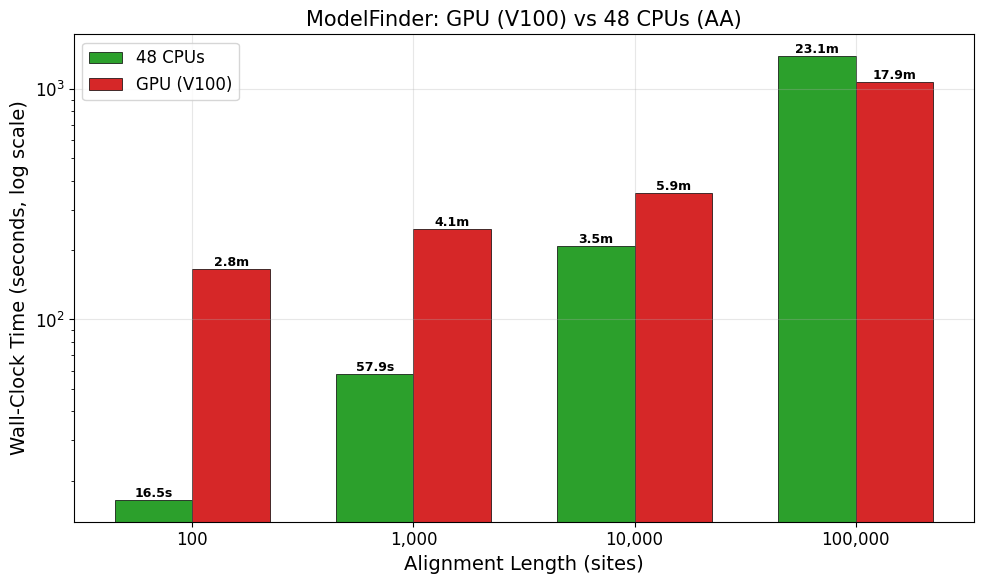

In [20]:
# Final summary bar chart: GPU vs 48 CPUs speedup
if 'GPU (V100)' in time_pivot.columns and '48 CPUs' in time_pivot.columns:
    common_idx = time_pivot[['GPU (V100)', '48 CPUs']].dropna().index
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x_labels = [f'{l:,}' for l in common_idx]
    gpu_times = [time_pivot.loc[l, 'GPU (V100)'] for l in common_idx]
    cpu48_times = [time_pivot.loc[l, '48 CPUs'] for l in common_idx]
    
    x = np.arange(len(x_labels))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, cpu48_times, width, label='48 CPUs', color=colors['48 CPUs'], edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x + width/2, gpu_times, width, label='GPU (V100)', color=colors['GPU (V100)'], edgecolor='black', linewidth=0.5)
    
    for bar, v in zip(bars1, cpu48_times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt_time(v), ha='center', va='bottom', fontsize=9, fontweight='bold')
    for bar, v in zip(bars2, gpu_times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt_time(v), ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_yscale('log')
    ax.set_xlabel('Alignment Length (sites)', fontsize=14)
    ax.set_ylabel('Wall-Clock Time (seconds, log scale)', fontsize=14)
    ax.set_title('ModelFinder: GPU (V100) vs 48 CPUs (AA)', fontsize=15)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'gpu_vs_48cpu_bars.png'), dpi=150, bbox_inches='tight')
    plt.show()